In [1]:
# General notebook settings
import logging
import warnings

import pypsa

warnings.filterwarnings("error", category=DeprecationWarning)
# pandas<3.0.3 sets the `locs` attribute deprecated in matplotlib>=3.11
warnings.filterwarnings("ignore", message="The locs attribute was deprecated")
logging.getLogger("gurobipy").propagate = False
pypsa.options.params.optimize.log_to_console = False

# Transport Delay

Multiport components as Links and Processes can model time-delayed energy transport via the `delay[x]` and `cyclic_delay[x]` attributes where `[x]` represents the number of the port. This is useful for representing transport delays in pipelines, shipping and other transport modes, or any process where energy withdrawn at `bus0` arrives at output ports after a configurable time lag.

Unlike links, processes use the convention to enumerate all `delay` and `cyclic_delay` attributes, i.e. `delay0`, `delay1`, ..., `cyclic_delay0`, ... Therefore they allows to have a delay at `bus0` in reference to the operation of the process `p`. Links on the other hand follow the convention on always refering to `p` at `bus0`. The `delay` attributes star with `delay` affecting `p1` at `bus1` and continue with `delay2`. This mirrors the convention of the `efficiency` attribute.   

So how do the attributes work?

- **`delay`**: The delay in units of elapsed time, measured against cumulative `n.snapshot_weightings.generators`. Energy withdrawn from `bus0` at snapshot `t` arrives at `bus1` at the first snapshot where the cumulative weighting since `t` reaches at least `delay`. For example, with uniform hourly snapshots (weightings = 1), `delay=3` means a 3-hour delay. With 3-hourly snapshots (weightings = 3), the same `delay=3` shifts delivery by one snapshot.

- **`cyclic_delay`**: If `True` (default), energy wraps cyclically from the end of the optimization horizon back to the start — energy sent in the last snapshots arrives at the first snapshots. If `False`, energy is lost at the tail of the horizon and the first snapshots receive nothing from delayed links.

- **Multi-port delays**: Each output port can have its own delay. For additional ports (`bus2`, `bus3`, ...), use `delay2`, `delay3`, ... and `cyclic_delay2`, `cyclic_delay3`, ....

This deep-dive example demonstrates time-delayed energy transport through [`Link`](../../user-guide/components/links.md) components. Note that the exact same behavior could be reproduced by using the [`Process`](../../user-guide/components/process.md) component aligning the attributes as described above. For a more basic introduction to delays in the context of chained reservoirs, see the [Chained Hydro-Reservoirs example](chained-hydro-reservoirs.ipynb).


## Setup

We set up a simple two-bus system: a production site with cheap generation connected to a demand site via a delayed link representing a hydrogen pipeline.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

import pypsa

n = pypsa.Network()
n.set_snapshots(range(8))

n.add("Bus", "production")
n.add("Bus", "demand")

n.add("Generator", "wind", bus="production", p_nom=100, marginal_cost=5)
n.add("Generator", "backup", bus="demand", p_nom=100, marginal_cost=80)
n.add("Load", "load", bus="demand", p_set=[10, 30, 50, 20, 40, 60, 25, 15])
n.sanitize()

/home/runner/work/PyPSA/PyPSA/pypsa/network/io.py:2082: FutureWarning: pandas infers the `str` dtype for string data since its version 3.0. PyPSA still converts it back to numpy object dtype on import, but will keep it from PyPSA 2.0 on. Set `pypsa.options.api.legacy_string_dtype` explicitly to suppress this warning.
  new_static = _coerce_string_dtypes(new_static)
INFO:pypsa.consistency:Sanitizing network...


INFO:pypsa.components._types.carriers:Adding 1 missing carriers: ['AC']


INFO:pypsa.components._types.carriers:Assigned colors to 1 carriers using 'tab10' palette.


INFO:pypsa.consistency:Network sanitization complete.


## Cyclic Delay

With `cyclic_delay=True` (the default), energy wraps around from the end of the optimization horizon to the start. The link has a 2-snapshot delivery delay and 95% efficiency.

In [3]:
n.add(
    "Link",
    "pipeline",
    bus0="production",
    bus1="demand",
    p_nom=100,
    efficiency=0.95,
    delay=2,
    cyclic_delay=True,
)

n.optimize();

/tmp/ipykernel_8238/753904955.py:12: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize();


INFO:linopy.model: Solve problem using Gurobi solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io: Writing time: 0.03s


Set parameter WLSAccessID


...

Reading time = 0.00 seconds


obj: 64 rows, 24 columns, 80 nonzeros


Set parameter LogToConsole to value 0


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 24 primals, 64 duals
Objective: 1.32e+03
Solver: gurobi
Runtime: 0.00s
Dual bound: 1.32e+03
Solver model: available
Solver message: 2



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper were not assigned to the network.


The output power `p1` is a time-shifted version of the input `p0`, scaled by the efficiency.

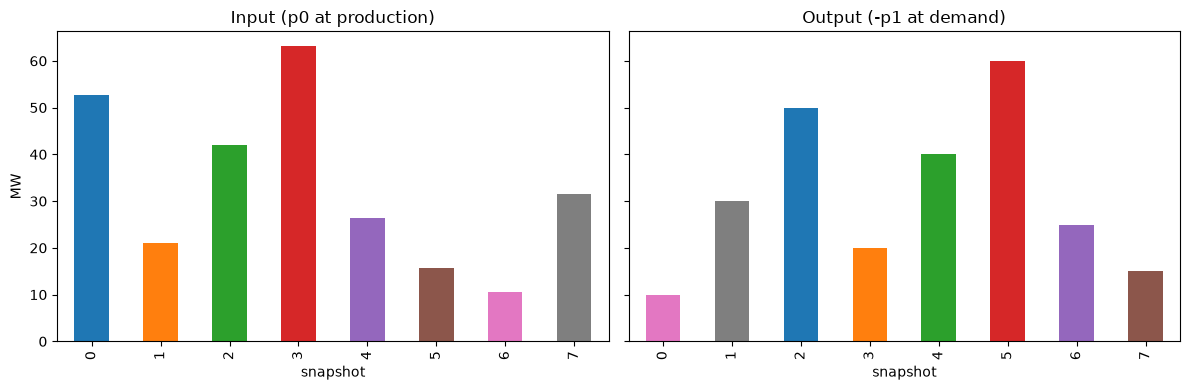

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
colors = [f"C{i}" for i in range(8)]
delay = 2
p0_colors = colors
p1_colors = colors[-delay:] + colors[:-delay]
n.links_t.p0["pipeline"].plot.bar(
    ax=axes[0], title="Input (p0 at production)", color=p0_colors
)
(-n.links_t.p1["pipeline"]).plot.bar(
    ax=axes[1], title="Output (-p1 at demand)", color=p1_colors
)
for ax in axes:
    ax.set_ylabel("MW")
plt.tight_layout()

## Non-Cyclic Delay

With `cyclic_delay=False`, the first snapshots receive no flow from the link (nothing was sent early enough to arrive), and energy sent in the last snapshots is lost (it would arrive beyond the horizon).

In [5]:
n.links.loc["pipeline", "cyclic_delay"] = False

n.optimize();

/tmp/ipykernel_8238/626982390.py:3: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize();


INFO:linopy.model: Solve problem using Gurobi solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io: Writing time: 0.02s


Set parameter WLSAccessID


...

Reading time = 0.00 seconds


obj: 64 rows, 24 columns, 78 nonzeros


Set parameter LogToConsole to value 0


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 24 primals, 64 duals
Objective: 4.31e+03
Solver: gurobi
Runtime: 0.00s
Dual bound: 4.31e+03
Solver model: available
Solver message: 2



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper were not assigned to the network.


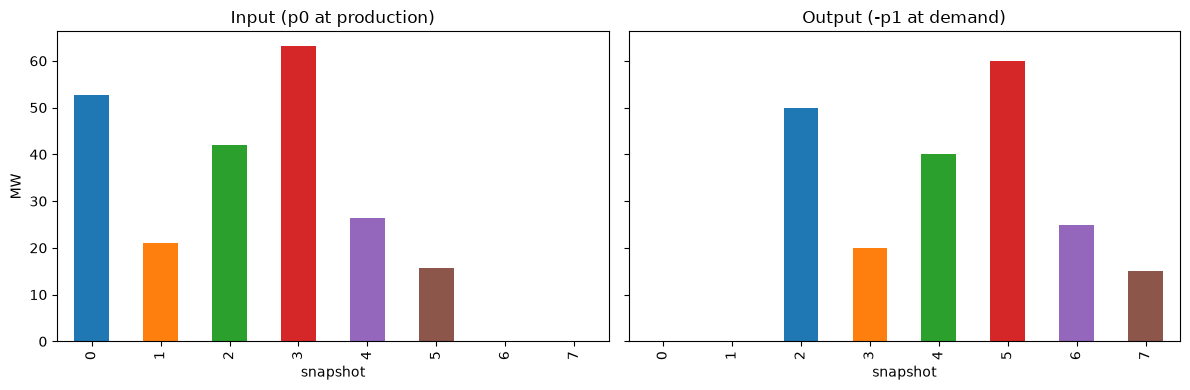

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
colors = [f"C{i}" for i in range(8)]
delay = 2
gray = "lightgray"
p0_colors = colors[: len(colors) - delay] + [gray] * delay
p1_colors = [gray] * delay + colors[: len(colors) - delay]
n.links_t.p0["pipeline"].plot.bar(
    ax=axes[0], title="Input (p0 at production)", color=p0_colors
)
(-n.links_t.p1["pipeline"]).plot.bar(
    ax=axes[1], title="Output (-p1 at demand)", color=p1_colors
)
for ax in axes:
    ax.set_ylabel("MW")
plt.tight_layout()

Notice that `p1` is zero for the first 2 snapshots and `p0` drops to zero for the last 2 snapshots.

## Multi-Port Delay

Each output port can have its own delay. Here we add a third bus representing a branch pipeline with a longer delay.

In [7]:
n.remove("Link", "pipeline")

n.add("Bus", "demand2")
n.add("Generator", "backup2", bus="demand2", p_nom=100, marginal_cost=80)
n.add("Load", "load2", bus="demand2", p_set=[5, 15, 25, 10, 20, 30, 12, 8])

n.add(
    "Link",
    "pipeline",
    bus0="production",
    bus1="demand",
    bus2="demand2",
    p_nom=100,
    efficiency=0.95,
    efficiency2=0.90,
    delay=2,
    delay2=4,
    cyclic_delay=True,
    cyclic_delay2=True,
)

n.optimize();

/tmp/ipykernel_8238/4124112339.py:22: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize();


INFO:linopy.model: Solve problem using Gurobi solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io: Writing time: 0.02s


Set parameter WLSAccessID


...

Reading time = 0.00 seconds


obj: 88 rows, 32 columns, 112 nonzeros


Set parameter LogToConsole to value 0


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 32 primals, 88 duals
Objective: 1.45e+04
Solver: gurobi
Runtime: 0.00s
Dual bound: 1.45e+04
Solver model: available
Solver message: 2



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper were not assigned to the network.


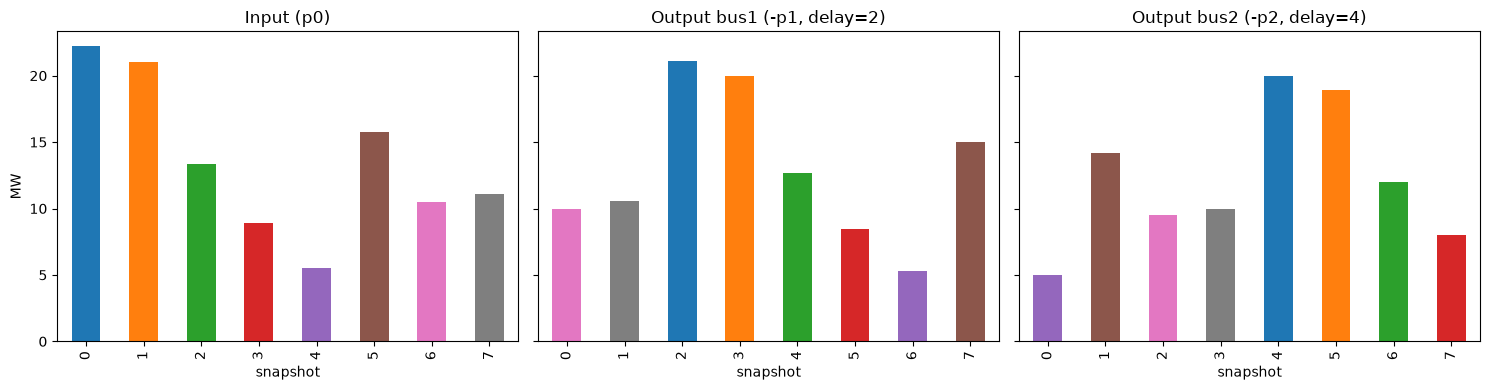

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = [f"C{i}" for i in range(8)]
p0_colors = colors
p1_colors = colors[-2:] + colors[:-2]
p2_colors = colors[-4:] + colors[:-4]
n.links_t.p0["pipeline"].plot.bar(ax=axes[0], title="Input (p0)", color=p0_colors)
(-n.links_t.p1["pipeline"]).plot.bar(
    ax=axes[1], title="Output bus1 (-p1, delay=2)", color=p1_colors
)
(-n.links_t.p2["pipeline"]).plot.bar(
    ax=axes[2], title="Output bus2 (-p2, delay=4)", color=p2_colors
)
for ax in axes:
    ax.set_ylabel("MW")
plt.tight_layout()

## Non-Uniform Snapshot Weightings

The delay is interpreted in `snapshot_weightings.generators` time units, not snapshot counts. With non-uniform weightings, the same `delay` value can shift by different numbers of snapshots.

In [9]:
n.remove("Link", "pipeline")
n.remove("Bus", "demand2")
n.remove("Generator", "backup2")
n.remove("Load", "load2")

n.snapshot_weightings.loc[:, "generators"] = [1, 2, 1, 2, 1, 2, 1, 2]

n.add(
    "Link",
    "pipeline",
    bus0="production",
    bus1="demand",
    p_nom=100,
    efficiency=0.95,
    delay=3,
    cyclic_delay=True,
)

n.optimize();

/tmp/ipykernel_8238/1769275034.py:19: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize();


INFO:linopy.model: Solve problem using Gurobi solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io: Writing time: 0.02s


Set parameter WLSAccessID


...

Reading time = 0.00 seconds


obj: 64 rows, 24 columns, 80 nonzeros


Set parameter LogToConsole to value 0


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 24 primals, 64 duals
Objective: 1.32e+03
Solver: gurobi
Runtime: 0.00s
Dual bound: 1.32e+03
Solver model: available
Solver message: 2



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper were not assigned to the network.


In [10]:
pd.DataFrame(
    {
        "weighting": n.snapshot_weightings.generators,
        "p0": n.links_t.p0["pipeline"],
        "p1": n.links_t.p1["pipeline"],
    }
)

,weighting,p0,p1
snapshot,,,
0,1.0,52.631579,-10.0
1,2.0,21.052632,-30.0
2,1.0,42.105263,-50.0
3,2.0,63.157895,-20.0
4,1.0,26.315789,-40.0
5,2.0,15.789474,-60.0
6,1.0,10.526316,-25.0
7,2.0,31.578947,-15.0


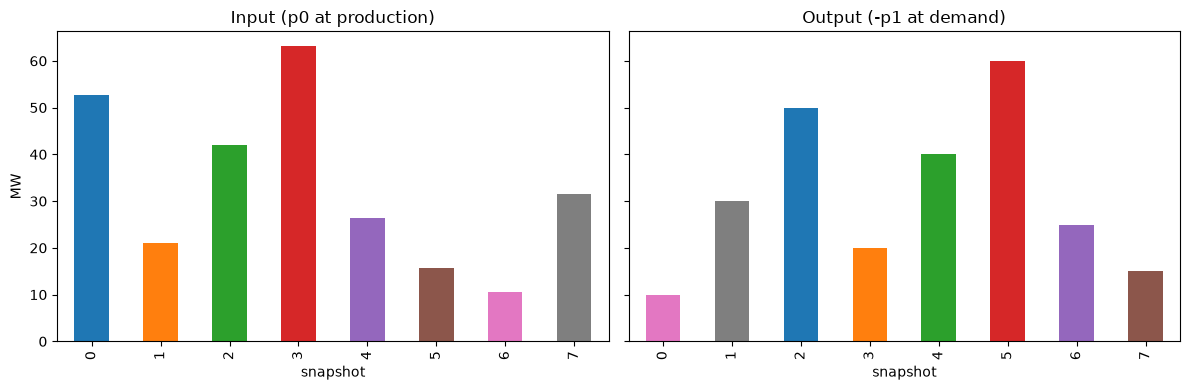

In [11]:
from pypsa.components._types.links import Links

src, _ = Links.get_delay_source_indexer(
    n.snapshots, n.snapshot_weightings.generators, delay=3, is_cyclic=True
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
colors = [f"C{i}" for i in range(8)]
p1_colors = [colors[s] for s in src]
n.links_t.p0["pipeline"].plot.bar(
    ax=axes[0], title="Input (p0 at production)", color=colors
)
(-n.links_t.p1["pipeline"]).plot.bar(
    ax=axes[1], title="Output (-p1 at demand)", color=p1_colors
)
for ax in axes:
    ax.set_ylabel("MW")
plt.tight_layout()

With non-uniform weightings `[1, 2, 1, 2, 1, 2, 1, 2]` and `delay=3`, the source-snapshot mapping depends on cumulative weighting sums rather than simple index arithmetic. Here, two snapshots with weights 1+2=3 exactly cover the delay, resulting in a 2-snapshot shift despite the delay value being 3.

## Sub-Snapshot Delays

When the delay is shorter than a single snapshot's weighting, the shift still rounds up to one snapshot. Here we use uniform weightings of 4 time units per snapshot with a delay of only 3. Since no snapshot boundary falls within the 3-unit window, the output is shifted by exactly one snapshot — the delay is effectively absorbed within the snapshot duration.

In [12]:
n.snapshot_weightings.loc[:, "generators"] = 4

n.links.loc["pipeline", "delay"] = 3

n.optimize();

/tmp/ipykernel_8238/3620165799.py:5: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize();


INFO:linopy.model: Solve problem using Gurobi solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io: Writing time: 0.02s


Set parameter WLSAccessID


...

Reading time = 0.00 seconds


obj: 64 rows, 24 columns, 80 nonzeros


Set parameter LogToConsole to value 0


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 24 primals, 64 duals
Objective: 1.32e+03
Solver: gurobi
Runtime: 0.00s
Dual bound: 1.32e+03
Solver model: available
Solver message: 2



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper were not assigned to the network.


In [13]:
src, _ = Links.get_delay_source_indexer(
    n.snapshots, n.snapshot_weightings.generators, delay=3, is_cyclic=True
)

pd.DataFrame(
    {
        "weighting": n.snapshot_weightings.generators,
        "p0": n.links_t.p0["pipeline"],
        "p1": n.links_t.p1["pipeline"],
        "source snapshot": src,
    }
)

,weighting,p0,p1,source snapshot
snapshot,,,,
0,4.0,31.578947,-10.0,7
1,4.0,52.631579,-30.0,0
2,4.0,21.052632,-50.0,1
3,4.0,42.105263,-20.0,2
4,4.0,63.157895,-40.0,3
5,4.0,26.315789,-60.0,4
6,4.0,15.789474,-25.0,5
7,4.0,10.526316,-15.0,6


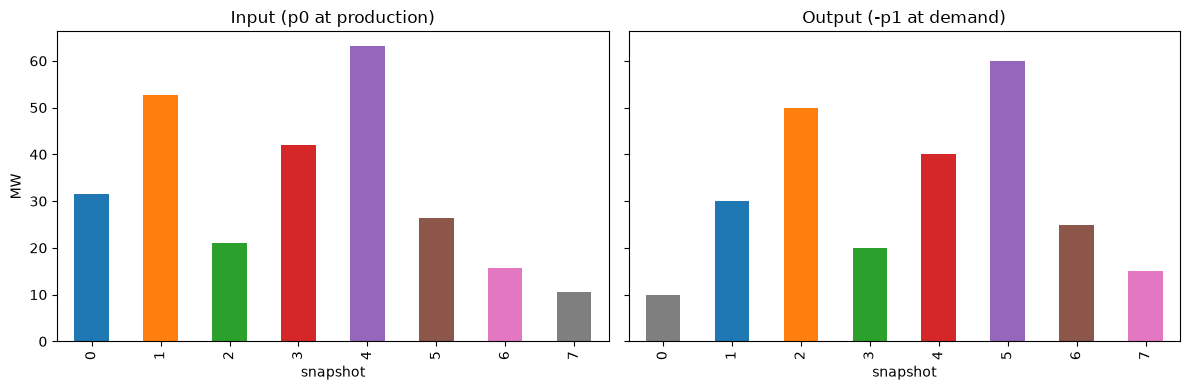

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
colors = [f"C{i}" for i in range(8)]
p1_colors = [colors[s] for s in src]
n.links_t.p0["pipeline"].plot.bar(
    ax=axes[0], title="Input (p0 at production)", color=colors
)
(-n.links_t.p1["pipeline"]).plot.bar(
    ax=axes[1], title="Output (-p1 at demand)", color=p1_colors
)
for ax in axes:
    ax.set_ylabel("MW")
plt.tight_layout()

The source-snapshot column confirms that each output snapshot draws from exactly one snapshot earlier (shift of 1), even though `delay=3`. With `weighting=4`, the cumulative snapshot starts are `[0, 4, 8, ...]` — the 3-unit delay never crosses more than one snapshot boundary, so the mapping `s(t) = t-1` (cyclically) applies uniformly. Compare this with the [previous section](#non-uniform-snapshot-weightings) where `delay=3` with mixed weightings `[1, 2, ...]` resulted in a 2-snapshot shift. See the [user guide](../../user-guide/components/links.md#time-delayed-energy-delivery) for details on how the source-snapshot mapping is computed.

## Super-Snapshot Delays

Conversely, when the delay exceeds a single snapshot's weighting, the shift spans multiple snapshots. Here we keep `weighting=4` but increase the delay to 5. The delay now crosses one full snapshot boundary, resulting in a 2-snapshot shift.

In [15]:
n.links.loc["pipeline", "delay"] = 5

n.optimize();

/tmp/ipykernel_8238/2580466178.py:3: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize();


INFO:linopy.model: Solve problem using Gurobi solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io: Writing time: 0.02s


Set parameter WLSAccessID


...

Reading time = 0.00 seconds


obj: 64 rows, 24 columns, 80 nonzeros


Set parameter LogToConsole to value 0


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 24 primals, 64 duals
Objective: 1.32e+03
Solver: gurobi
Runtime: 0.00s
Dual bound: 1.32e+03
Solver model: available
Solver message: 2



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper were not assigned to the network.


In [16]:
src, _ = Links.get_delay_source_indexer(
    n.snapshots, n.snapshot_weightings.generators, delay=5, is_cyclic=True
)

pd.DataFrame(
    {
        "weighting": n.snapshot_weightings.generators,
        "p0": n.links_t.p0["pipeline"],
        "p1": n.links_t.p1["pipeline"],
        "source snapshot": src,
    }
)

,weighting,p0,p1,source snapshot
snapshot,,,,
0,4.0,52.631579,-10.0,6
1,4.0,21.052632,-30.0,7
2,4.0,42.105263,-50.0,0
3,4.0,63.157895,-20.0,1
4,4.0,26.315789,-40.0,2
5,4.0,15.789474,-60.0,3
6,4.0,10.526316,-25.0,4
7,4.0,31.578947,-15.0,5


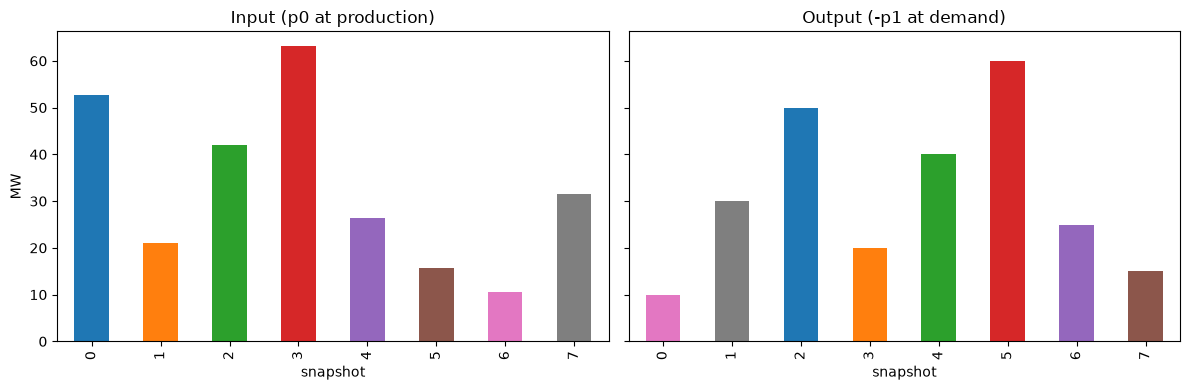

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
colors = [f"C{i}" for i in range(8)]
p1_colors = [colors[s] for s in src]
n.links_t.p0["pipeline"].plot.bar(
    ax=axes[0], title="Input (p0 at production)", color=colors
)
(-n.links_t.p1["pipeline"]).plot.bar(
    ax=axes[1], title="Output (-p1 at demand)", color=p1_colors
)
for ax in axes:
    ax.set_ylabel("MW")
plt.tight_layout()

With `delay=5` and `weighting=4`, each snapshot spans 4 time units, so a 5-unit delay crosses one full snapshot plus 1 unit into the next — yielding a 2-snapshot shift (`s(t) = t-2`). Compare this with the [sub-snapshot case](#sub-snapshot-delays) above where `delay=3 < weighting=4` produced only a 1-snapshot shift. The general rule: the number of snapshot shifts equals `ceil(delay / weighting)` for uniform weightings.